In [1]:
from maelzel.snd import pyin
from maelzel.snd.audiosample import Sample
from maelzel.snd import numpysnd as npsnd
import bpf4
import numpy as np
from pitchtools.vectorized import amp2db


In [2]:
sample = Sample("../snd/voiceover-fragment-48k.flac")

In [3]:
sample.detectMinFreq(refine=True)

(87.35661247885199, 1.496)

In [4]:
times, freqs, conf, voiced = pyin.pyin(sample.samples, sr=sample.sr, minFreq=80, maxFreq=400, voicedProb=0.9, 
                                       v2u=0.01, u2v=0.7, bins=320*1,
                                       hopSize=256, frameSize=2048, window='hann')
rms = sample.rmsAt(times)


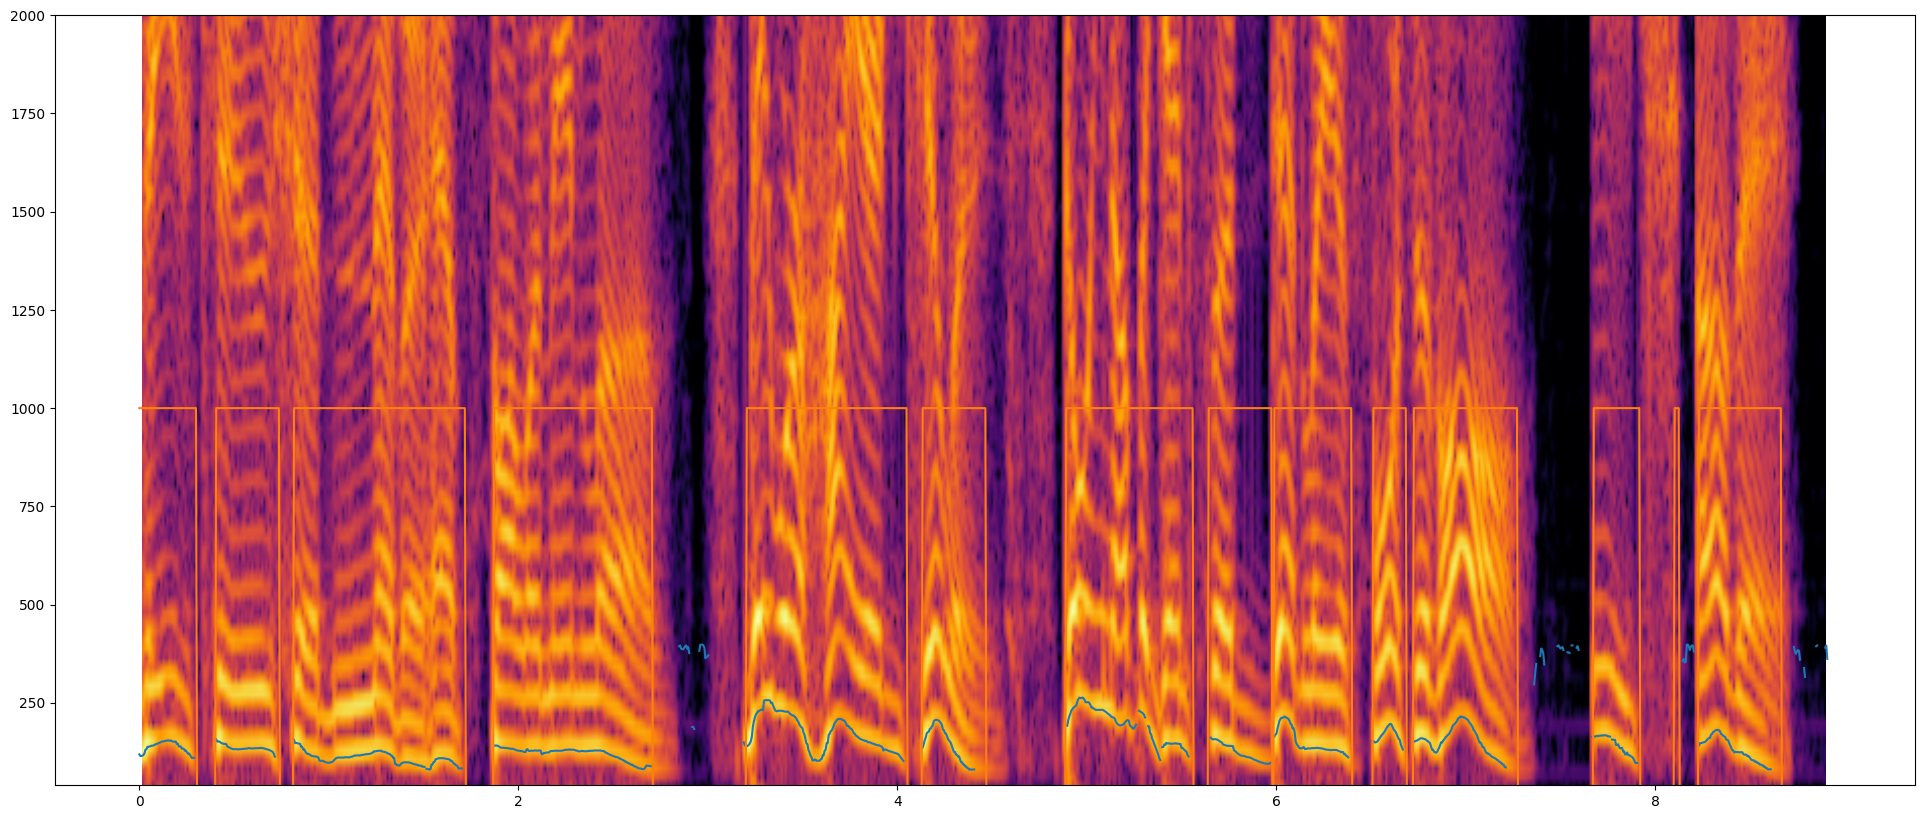

In [5]:
ax = sample.plotSpectrogram(maxfreq=2000)
ax.plot(times, freqs)

voiced2 = npsnd.schmitt(conf, 0.6, 0.3, minhold=0).astype(int)
sound = npsnd.schmitt(rms, 0.1, 0.01).astype(int)
valid = voiced2 * sound

ax.plot(times, valid * 1000)

In [6]:
from maelzel.snd import pitchtrack

In [7]:
pitchtrack.detectMinFrequency(sample.samples[:sample.sr*2], sr=sample.sr, refine=False)

(97.78097300178867, 1.0026666666666666)

In [8]:
times, f0, confidence, voiced = pyin.pyin(sample.samples, sr=sample.sr, minFreq=30, maxFreq=2000, frameSize=2048, hopSize=2048//2)

In [9]:
mask = confidence > 0.3 * (f0 > 30)

In [10]:
sel = f0[mask]
sel

array([          nan,           nan,  138.8897278 ,  140.52404823,
        143.85060872,  147.25591732,  152.51562286,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
        148.98868301,  145.54330402,  137.27441481,  132.54032275,
        130.9988545 ,  130.9988545 ,  132.54032275,  134.0999295 ,
        134.0999295 ,  134.0999295 ,  135.67788821,  132.54032275,
        129.47531382,  125.0101842 ,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,           nan,           nan,           nan,
                 nan,  102.46521543,   98.93156524,   97.780973  ,
        101.2735262 ,  109.91567011,  111.20905176,  111.20905176,
        111.20905176,  113.84165196,  116.53657247,  116.53657247,
        119.29528859,  119.29528859,  126.48118354,  127.96949